# 01 Loading and Exploring MRI Data (SIMON Dataset)

This notebook introduces the structure of anatomical MRI data stored in NIfTI format. Explore spatial dimensions, voxel resolution, image orientation, and voxel intensity characteristics.

In [1]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [2]:
fmri_path = "../data/SIMON_data/SIMON_BIDS/sub-032633/ses-001/anat/sub-032633_ses-001_run-1_T1w.nii.gz"
os.path.exists(fmri_path)

True

In [3]:
img = nib.load(fmri_path)

In [4]:
img

In [6]:
img.shape

(171, 256, 256)

Structural MRI data is 3D, with shape (X, Y, Z).

Each voxel represents tissue intensity at a spatial location.

Unlike fMRI, there is no time dimension.

## explore nibabel datastructure

### image header

In [8]:
header = img.header

In [10]:
print(header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [  3 171 256 256   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.  1.  1.  1.  0.  0.  0.  0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'')
aux_file        : np.bytes_(b'')
qform_code      : scanner
sform_code      : scanner
quatern_b       : -0.0
quatern_c       : 1.0
quatern_d       : 0.0
qoffset_x       : 82.60936
qoffset_y       : -79.69107
qof

#### meaning for image headers

| Field           | Description                                                       | Example / Notes                                  |
|-----------------|-------------------------------------------------------------------|-------------------------------------------------| 
| **dim**         | Data dimensions (e.g. 3D, 4D)                                    | [3, 171, 256, 256, 1, 1, 1, 1]                  |
| **datatype**    | Data type code (storage format)                                  | int16 (16-bit signed integer)                    |
| **bitpix**      | Number of bits per voxel                                         | 16                                              |
| **pixdim**      | Voxel size in mm per dimension                                  | [-1, 1, 1, 1, 0, 0, 0, 0] — spatial resolution 1mm³ |
| **vox_offset**  | Byte offset to image data                                        | 0.0                                             |
| **scl_slope**   | Scale slope for intensity values                                | NaN (no scaling)                                 |
| **scl_inter**   | Scale intercept for intensity values                            | NaN (no scaling)                                 |
| **qform_code**  | Coordinate system code for quaternion transform                 | scanner (scanner coordinate system)              |
| **sform_code**  | Coordinate system code for affine transform                     | scanner (scanner coordinate system)              |
| **quatern_b/c/d** | Quaternion parameters representing rotation                     | -0.0, 1.0, 0.0                                  |
| **qoffset_x/y/z** | Translation offsets in mm                                         | 82.60936, -79.69107, -200.95273                  |
| **srow_x/y/z**  | Affine transform rows mapping voxel indices to mm coordinates   | See matrix rows, e.g. [-1, 0, 0, 82.60936] etc. |
| **xyzt_units**  | Units of measurement for spatial (x,y,z) and temporal (t) dims | 2 (millimeters)                                  |
| **slice_duration** | Time between slices (if applicable)                             | 0.0 (not applicable for structural MRI)         |
| **descrip**     | Optional description string                                     | ''                                              |
| **magic**       | NIfTI magic string identifying file type                        | 'n+1'                                           |

---

**Usage Notes:**

- **dim** tells you the data shape (3D or 4D).
- **datatype** and **bitpix** define how voxel data is stored.
- **pixdim** provides voxel size, crucial for spatial resolution.
- **qform_code** and **sform_code** indicate which spatial transform is valid.
- **srow_x/y/z** define the affine matrix that maps voxel coordinates to real-world mm coordinates.
- **scl_slope** and **scl_inter** apply scaling to raw voxel intensities if needed.
- Units (xyzt_units) confirm whether spatial units are in mm or something else.



### the affine matrix

data.shape = (171, 256, 256) for (i, j, k) = (slice, row, column) are just voxel indices — positions in a 3D grid.

**The affine matrix converts voxel indices → real-world coordinates (mm)**
The affine is a 4×4 transformation matrix:

$$\begin{bmatrix} x \\ y \\ z \\ 1 \end{bmatrix} = \text{Affine} \cdot \begin{bmatrix} i \\ j \\ k \\ 1 \end{bmatrix}$$

Structure of the Affine Matrix Here is:
`srow_x : [-1.      -0.      -0.      82.60936]
srow_y : [ -0.        1.       -0.      -79.69107]
srow_z : [   0.         0.         1.      -200.95273]`

**What do X, Y, Z directions mean?**
Neuroimaging uses a Right-Anterior-Superior (RAS) coordinate system:
| Axis  | Positive Direction | Negative Direction |
| ----- | ------------------ | ------------------ |
| **X** | Right side of head | Left side          |
| **Y** | Front (anterior)   | Back (posterior)   |
| **Z** | Up (superior)      | Down (inferior)    |

In [12]:
data = img.get_fdata()
data.shape

(171, 256, 256)

In [14]:
print("Data type:", data.dtype)
print("Min intensity:", np.min(data))
print("Max intensity:", np.max(data))

Data type: float64
Min intensity: 0.0
Max intensity: 4095.0


MRI intensity values reflect **relative signal strength** determined by tissue properties and scanner settings, not absolute physical quantities.

In [15]:
voxel_sizes = img.header.get_zooms()
print("Voxel size (mm):", voxel_sizes)

Voxel size (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))


In [16]:
img.affine

array([[  -1.        ,   -0.        ,   -0.        ,   82.60935974],
       [  -0.        ,    1.        ,   -0.        ,  -79.69107056],
       [   0.        ,    0.        ,    1.        , -200.95272827],
       [   0.        ,    0.        ,    0.        ,    1.        ]])

## simple visulisation

NumPy arrays follow matrix indexing conventions (row-major order with origin at the top-left), while neuroimaging uses anatomical coordinate conventions. Transposing the slice and setting origin="lower" ensures the displayed orientation better matches anatomical directions.

Sagittal view: slicing the brain from left to right.

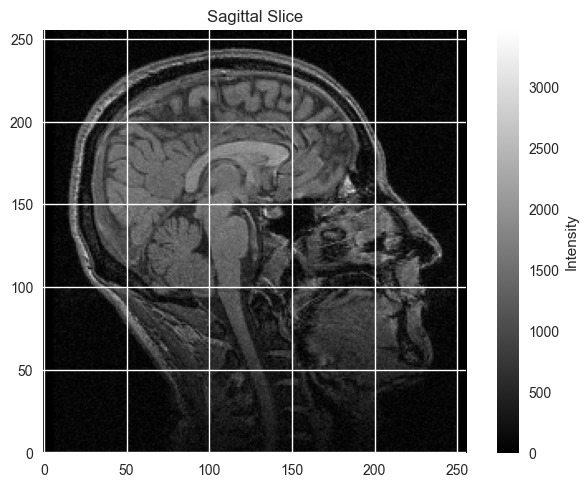

In [17]:
x = data.shape[0] // 2


plt.imshow(data[x, :, :].T, cmap="gray", origin="lower")
plt.title("Sagittal Slice")
plt.colorbar(label="Intensity")
plt.show()

Coronal view: slicing from front to back.

In [ ]:
y = data.shape[1] // 2

plt.imshow(data[:, y, :].T, cmap="gray", origin="lower")
plt.title("Coronal Slice")
plt.colorbar(label="Intensity")
plt.show()

Axial view: slicing from top to bottom.

In [ ]:
z = data.shape[2] // 2

plt.imshow(data[:, :, z].T, cmap="gray", origin="lower")
plt.title("Axial Slice")
plt.colorbar(label="Intensity")
plt.show()

## intensity histogram

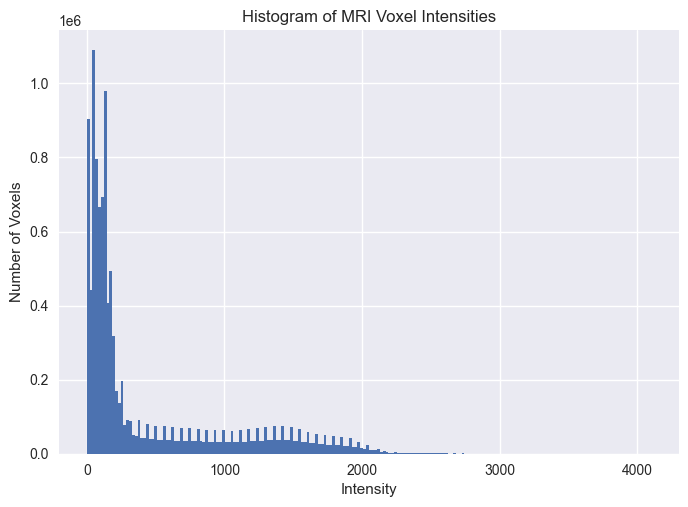

In [19]:
plt.hist(data.flatten(), bins=200)
plt.title("Histogram of MRI Voxel Intensities")
plt.xlabel("Intensity")
plt.ylabel("Number of Voxels")
plt.show()